# True Parameters at 1 PA Model

```python
m1 = 1e6
m2 = 10
a = 0.8 
e0 = 0.4 
xI0 = 1.0
dist = 0.4

qS = xp.pi/4
phiS = 1.0
qK = 1
phiK = xp.pi/3

Phi_phi0 = 0.9
Phi_theta0 = 0.5
Phi_r0 = 0.4

dt = 10.0
T = 1.0

chi2 = 0.0

dev_0_p = 0.0
dev_0_e = 0.0
dev_1_p = 0.0
dev_1_e = 0.0
dev_2_p = 0.0
dev_2_e = 0.0

evolve_1PA = True
evolve_primary = False
evolve_2PA = False
deviation_included = True

p0 = 7.5

best_fit = [13.81561299, 10.00055693,  0.80008266,  7.49954817,  0.39998251, 0.78536073,  0.99998866,  0.90006928,  0.39977347]

In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.stats import chi2


from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True
from parismc.sampler import SamplerConfig
from parismc.sampler import Sampler

from smt.sampling_methods import LHS

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself

startup


In [2]:
#waveform class setup
waveform_class = SuperKludgeWaveform
max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
}

waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                              sum_kwargs=sum_kwargs,
                              use_gpu=use_gpu)

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


In [3]:
if(use_gpu):
    xp=cp
else:
    xp=np

best_fit = [13.81556871, 10.00053383 , 0.80004804 , 7.49977467,  0.39998433,  0.78466984, 1.00056143 , 0.96234993 , 0.33422898]
#logm1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,dev0p_,dev0e_ = params[i]
logm1 = best_fit[0]
m1= np.exp(logm1)
m2 = best_fit[1]
a = best_fit[2]
p0= best_fit[3]
e0 = best_fit[4]
xI0 = 1.0
dist = 0.4
qS = best_fit[5]
phiS = best_fit[6]
qK = 1 
phiK = np.pi/3
Phi_phi0 = best_fit[7]
Phi_theta0 =0.5
Phi_r0 = best_fit[8]

dt = 10.0
T = 1.0

chi2 = 0.0

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True


print(use_gpu)

pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0']
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

emri_kwargs = {"T":T, "dt":dt}

param_names_com = ['m1','m2','a','p0','e0','xI0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_theta0','Phi_r0',"chi2",
               "evolve_1PA","evolve_primary","evolve_2PA","deviation_included","dev0p","dev0e","dev1p","dev1e","dev2p","dev2e"]

True


In [4]:
der_order = 8
Ndelta=16
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )
                   

SNR = sef.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

waveform shape:  (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000058.1537265892), 10.00053383, 0.80004804, 7.49977467, 0.39998433, 1.0, 0.4, 0.78466984, 1.00056143, 1, 1.0471975511965976, 0.96234993, 0.5, 0.33422898, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
SNR:  136.79194904097386


Body is not plunging, Fisher should be stable.
waveform shape:  (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000058.1537265892), 10.00053383, 0.80004804, 7.49977467, 0.39998433, 1.0, 0.4, 0.78466984, 1.00056143, 1, 1.0471975511965976, 0.96234993, 0.5, 0.33422898, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 136.79194904097386
calculating stable deltas...
Gamma_ii for m1: 22242.673809830416
Gamma_ii for m1: 22242.67380989719
Gamma_ii for m1: 22242.673810062035
Gamma_ii for m1: 22242.673809976153
Gamma_ii for m1: 22242.67381073697
Gamma_ii for m1: 22242.673810181543
Gamma_ii for m1: 22242.673813275524
Gamma_ii for m1: 22242.67380222726
Gamma_ii for m1: 22242.673835440317
Gamma_ii for m1: 22242.6738546864
Gamma_ii for m1: 22242.673678025745
Gamma_ii for m1: 22242.673974776113
Gamma_ii for m1: 22242.673607499415
Gamma_ii for m1: 22242.67316439844
Gamma_ii for m1: 22242.673369659355
Gamma_ii for m1: 22242.66869162705
[np.floa

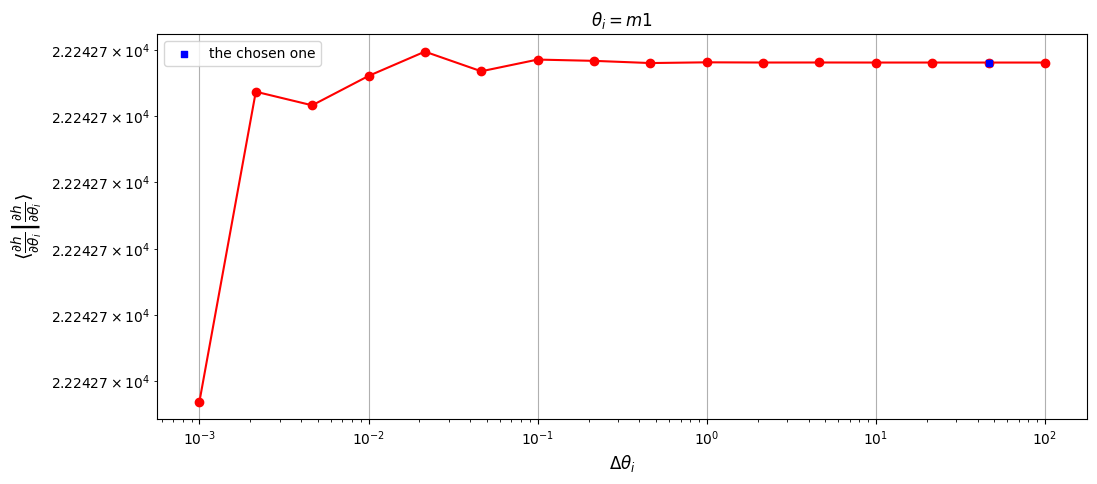

Gamma_ii for m2: 14182557881679.248
Gamma_ii for m2: 14182557881142.535
Gamma_ii for m2: 14182557880667.258
Gamma_ii for m2: 14182557879401.834
Gamma_ii for m2: 14182557880686.84
Gamma_ii for m2: 14182557876290.252
Gamma_ii for m2: 14182557876037.928
Gamma_ii for m2: 14182557888286.52
Gamma_ii for m2: 14182557892312.713
Gamma_ii for m2: 14182557794358.316
Gamma_ii for m2: 14182558133650.197
Gamma_ii for m2: 14182556865379.021
Gamma_ii for m2: 14182558858116.904
Gamma_ii for m2: 14182556604256.232
Gamma_ii for m2: 14182556820504.773
Gamma_ii for m2: 14182556837965.945
[np.float64(3.784316588889978e-11), np.float64(3.351139813769893e-11), np.float64(8.92239495079269e-11), np.float64(9.060466173911141e-11), np.float64(3.0999964385655803e-10), np.float64(1.7791164397524734e-11), np.float64(8.636377086104618e-10), np.float64(2.8388344260221873e-10), np.float64(6.906680579390292e-09), np.float64(2.3923179278522068e-08), np.float64(8.942471994434383e-08), np.float64(1.405062304163839e-07), np

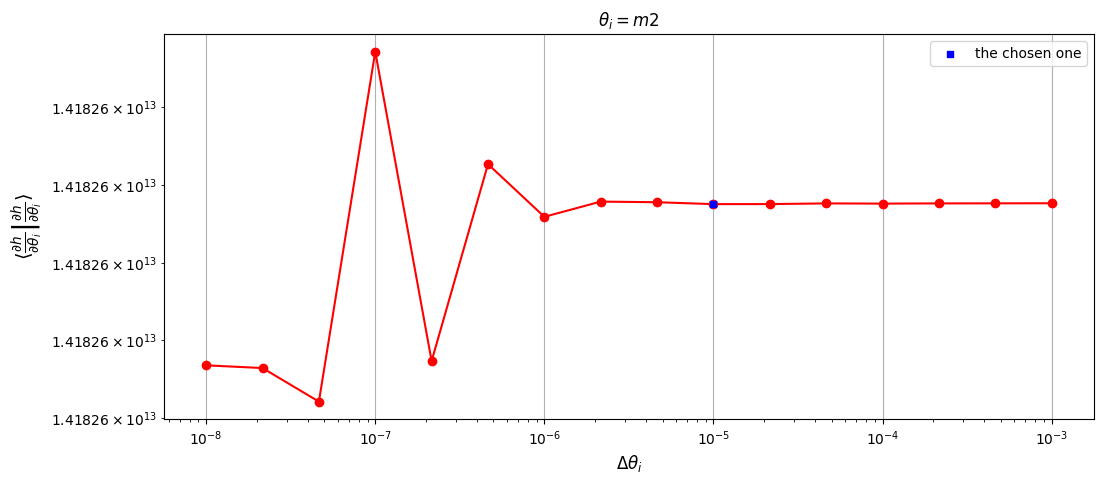

Gamma_ii for a: 1814979499260671.5
Gamma_ii for a: 1814979443560028.5
Gamma_ii for a: 1814979430494350.8
Gamma_ii for a: 1814980176619104.8
Gamma_ii for a: 1814978764166678.8
Gamma_ii for a: 1814979124990007.2
Gamma_ii for a: 1814985997376712.2
Gamma_ii for a: 1814966127303311.2
Gamma_ii for a: 1814985811852087.2
Gamma_ii for a: 1815016674483524.8
Gamma_ii for a: 1814791130683553.0
Gamma_ii for a: 1815113272586487.0
Gamma_ii for a: 1814997151081105.2
Gamma_ii for a: 1815159493197195.0
Gamma_ii for a: 1817175283617300.8
Gamma_ii for a: 1820929401079405.2
[np.float64(3.068940708812924e-08), np.float64(7.198802107879133e-09), np.float64(4.1109250867404e-07), np.float64(7.782198083449792e-07), np.float64(1.988030184655631e-07), np.float64(3.7864681683125905e-06), np.float64(1.0947903160332302e-05), np.float64(1.0845566200825044e-05), np.float64(1.7004048431831718e-05), np.float64(0.00012428085863897597), np.float64(0.00017747757553166727), np.float64(6.397889126855218e-05), np.float64(8.94

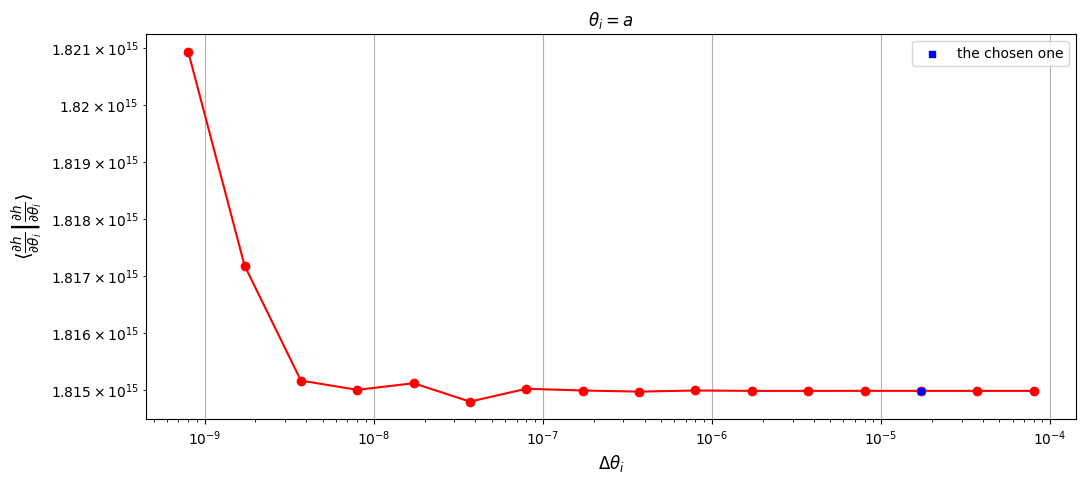

Gamma_ii for p0: 1172588341058052.0
Gamma_ii for p0: 1172588333683648.5
Gamma_ii for p0: 1172588316272061.2
Gamma_ii for p0: 1172588325341123.0
Gamma_ii for p0: 1172588412279424.2
Gamma_ii for p0: 1172588289927491.2
Gamma_ii for p0: 1172588697846210.0
Gamma_ii for p0: 1172589281272397.5
Gamma_ii for p0: 1172589866728238.0
Gamma_ii for p0: 1172581415220887.2
Gamma_ii for p0: 1172609079666718.5
Gamma_ii for p0: 1172575757340891.0
Gamma_ii for p0: 1172634240550404.5
Gamma_ii for p0: 1172663392685866.0
Gamma_ii for p0: 1172861573631377.8
Gamma_ii for p0: 1172864407243509.8
[np.float64(6.288996136294098e-09), np.float64(1.4848849343267892e-08), np.float64(7.734224837486487e-09), np.float64(7.414221421564148e-08), np.float64(1.0434347166094061e-07), np.float64(3.4787877411683895e-07), np.float64(4.975537443655582e-07), np.float64(4.992844106128426e-07), np.float64(7.20760813794574e-06), np.float64(2.3592215266756122e-05), np.float64(2.8418057953941255e-05), np.float64(4.987335990295617e-05),

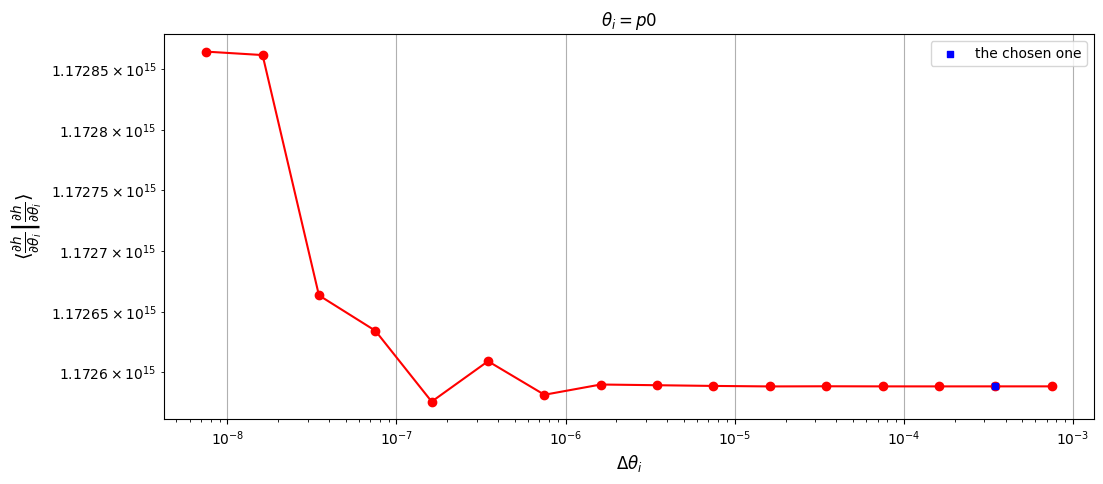

Gamma_ii for e0: 3816674529816037.0
Gamma_ii for e0: 3816674301299729.0
Gamma_ii for e0: 3816672794800413.5
Gamma_ii for e0: 3816673325410926.0
Gamma_ii for e0: 3816677549960787.0
Gamma_ii for e0: 3816675494846151.0
Gamma_ii for e0: 3816670366362642.5
Gamma_ii for e0: 3816650620648023.5
Gamma_ii for e0: 3816761777774422.0
Gamma_ii for e0: 3816806497865951.5
Gamma_ii for e0: 3816866869159453.0
Gamma_ii for e0: 3816138800373974.5
Gamma_ii for e0: 3817664711202126.5
Gamma_ii for e0: 3818745724384410.5
Gamma_ii for e0: 3806359507921225.5
Gamma_ii for e0: 3812385822690382.0
[np.float64(5.987314870492909e-08), np.float64(3.9471534409561035e-07), np.float64(1.390243458792406e-07), np.float64(1.1068658029660912e-06), np.float64(5.384567377486309e-07), np.float64(1.3437061669508388e-06), np.float64(5.1735714325476835e-06), np.float64(2.912341216729445e-05), np.float64(1.1716625287266685e-05), np.float64(1.5816976481234964e-05), np.float64(0.00019078676734901536), np.float64(0.000399697444271242

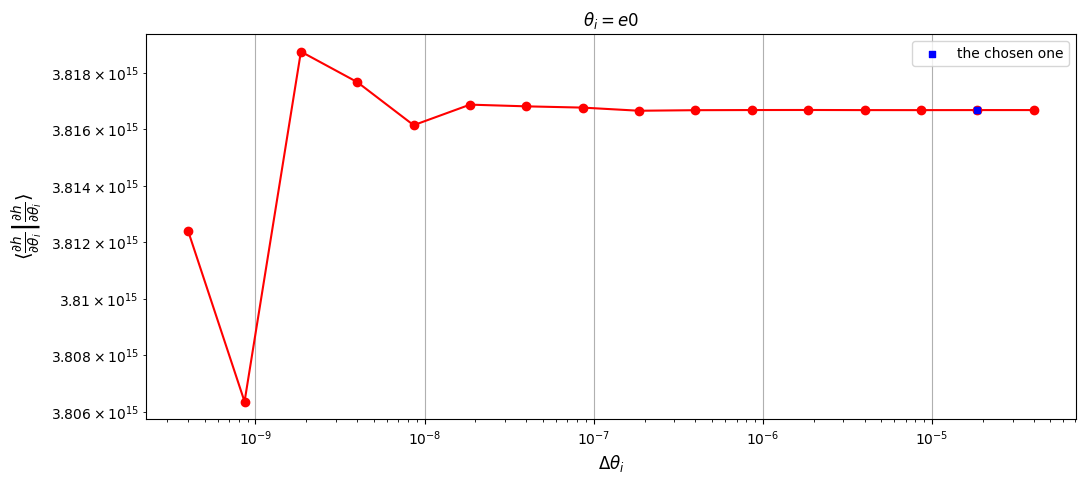

Gamma_ii for qS: 55635.28698041484
Gamma_ii for qS: 55635.287075718756
Gamma_ii for qS: 55635.28707592764
Gamma_ii for qS: 55635.28707592758
Gamma_ii for qS: 55635.28707592799
Gamma_ii for qS: 55635.287075931585
Gamma_ii for qS: 55635.28707592501
Gamma_ii for qS: 55635.28707592798
Gamma_ii for qS: 55635.287075938875
Gamma_ii for qS: 55635.28707597918
Gamma_ii for qS: 55635.28707598417
Gamma_ii for qS: 55635.28707582102
Gamma_ii for qS: 55635.287075663626
Gamma_ii for qS: 55635.28707758379
Gamma_ii for qS: 55635.287075267544
Gamma_ii for qS: 55635.28707855704
[np.float64(1.7130119666848495e-09), np.float64(3.754550000982611e-12), np.float64(1.0462363721432624e-15), np.float64(7.323654605002783e-15), np.float64(6.46050959798418e-14), np.float64(1.1822471005219411e-13), np.float64(5.3488834525823904e-14), np.float64(1.9577698113726824e-13), np.float64(7.243879081620195e-13), np.float64(8.971476891119351e-14), np.float64(2.9324697715766636e-12), np.float64(2.8290231502888038e-12), np.float

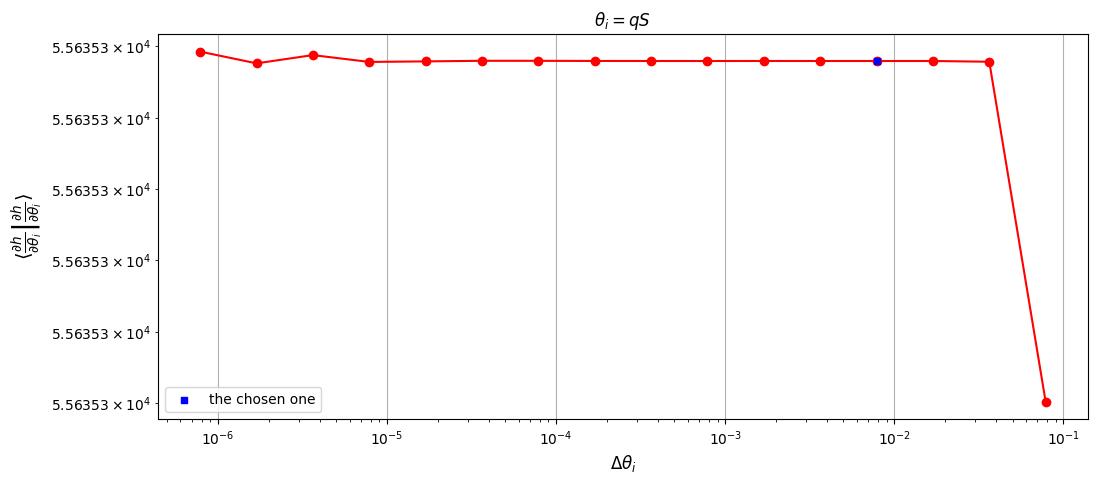

Gamma_ii for phiS: 1103253.0428118957
Gamma_ii for phiS: 1103253.0427754424
Gamma_ii for phiS: 1103253.0427753618
Gamma_ii for phiS: 1103253.0427753618
Gamma_ii for phiS: 1103253.0427753618
Gamma_ii for phiS: 1103253.0427753618
Gamma_ii for phiS: 1103253.0427753618
Gamma_ii for phiS: 1103253.0427753618
Gamma_ii for phiS: 1103253.0427753623
Gamma_ii for phiS: 1103253.0427753618
Gamma_ii for phiS: 1103253.0427753595
Gamma_ii for phiS: 1103253.0427753625
Gamma_ii for phiS: 1103253.0427753597
Gamma_ii for phiS: 1103253.042775351
Gamma_ii for phiS: 1103253.0427754072
Gamma_ii for phiS: 1103253.0427753932
[np.float64(3.304170588336326e-11), np.float64(7.301987810664208e-14), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(4.2208022026960717e-16), np.float64(4.2208022026960737e-16), np.float64(2.1104011013480413e-15), np.float64(2.743521431752446e-15), np.float64(2.532481321617649e-15), np.float64(7.808484074987812e-15), np.float64(5.08606665424

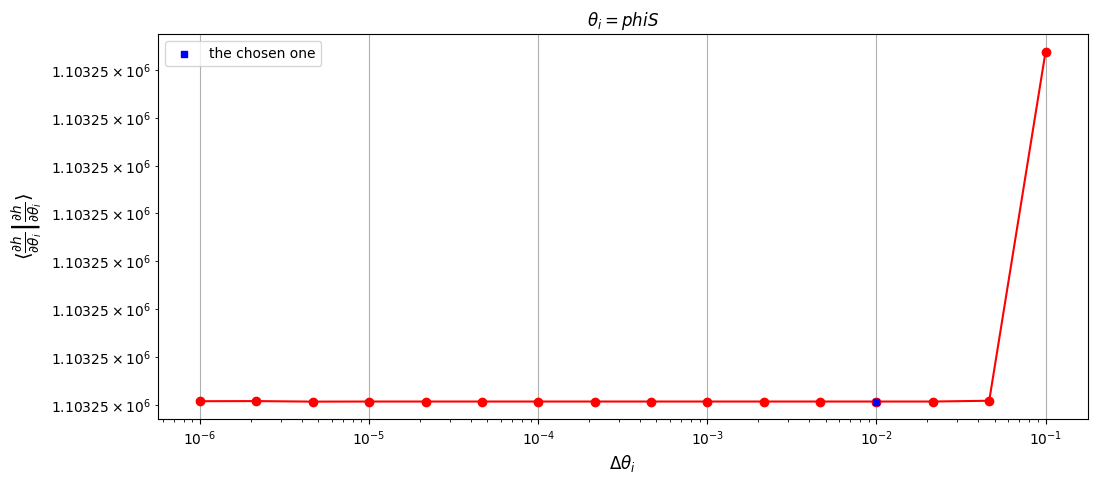

stable deltas: {'m1': 46.418587593007466, 'm2': 1.0000533829999986e-05, 'a': 1.723651251068016e-05, 'p0': 0.0003481087036288395, 'e0': 1.8565627997480914e-05, 'qS': 0.007846698399999998, 'phiS': 0.010005614300000005, 'Phi_phi0': 0.0, 'Phi_r0': 0.0}
Time taken to compute stable deltas is 221.40823936462402 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 14.962350845336914 seconds


In [5]:
param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}


Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,return_derivatives=True
            )


In [6]:
def logmasstransform(Fisher, m1, index_of_m1 = 0):    
    J = np.eye(len(Fisher))
    J[index_of_m1,index_of_m1] = m1
    
    return J.T@Fisher@J
fisher_=logmasstransform(Fisher[-1], m1, index_of_m1 = 0)
cov=np.linalg.inv(fisher_)
std= np.sqrt(np.diag(cov))
params_truth_in = np.array([np.log(1e6), 10, 0.8, 7.5, 0.4, np.pi/4, 1.0,  0.9,0.4])

In [7]:
pd.DataFrame(fisher_)

,0,1,2,3,4,5,6,7,8
0,2.224526e+16,-5.492391e+14,5.988138e+15,5.097965e+15,8.882092e+15,-2.846594e+10,1.330850e+11,-3.496650e+10,-1.305121e+10
1,-5.492391e+14,1.418256e+13,-1.580272e+14,-1.273204e+14,-2.064906e+14,6.384835e+08,-2.984169e+09,7.840022e+08,2.311469e+08
2,5.988138e+15,-1.580272e+14,1.814979e+15,1.401734e+15,2.188983e+15,-6.935506e+09,3.241824e+10,-8.516718e+09,-1.690544e+09
3,5.097965e+15,-1.273204e+14,1.401734e+15,1.172588e+15,2.006593e+15,-6.420986e+09,3.001872e+10,-7.886951e+09,-2.717776e+09
4,8.882092e+15,-2.064906e+14,2.188983e+15,2.006593e+15,3.816674e+15,-1.283709e+10,6.003689e+10,-1.577512e+10,-7.194376e+09
5,-2.846594e+10,6.384835e+08,-6.935506e+09,-6.420986e+09,-1.283709e+10,5.563529e+04,-2.350634e+05,6.177310e+04,2.852859e+04
6,1.330850e+11,-2.984169e+09,3.241824e+10,3.001872e+10,6.003689e+10,-2.350634e+05,1.103253e+06,-2.890648e+05,-1.334812e+05
7,-3.496650e+10,7.840022e+08,-8.516718e+09,-7.886951e+09,-1.577512e+10,6.177310e+04,-2.890648e+05,7.597087e+04,3.507256e+04
8,-1.305121e+10,2.311469e+08,-1.690544e+09,-2.717776e+09,-7.194376e+09,2.852859e+04,-1.334812e+05,3.507256e+04,3.661759e+04


In [8]:
from scipy.stats import chi2
def plot_confidence_ellipse(ax, mean, cov, i, j, levels=[0.90, 0.99]):

    # Extract 2x2 sub-covariance
    cov2 = cov[np.ix_([i, j], [i, j])]
    mean2 = mean[[i, j]]
    
    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(cov2)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    theta = np.linspace(0, 2*np.pi, 400)

    for p in levels:
        chi2_val = chi2.ppf(p, df=2)
        r1 = np.sqrt(eigvals[0] * chi2_val)
        r2 = np.sqrt(eigvals[1] * chi2_val)
        
        ellipse = np.vstack([r1*np.cos(theta), r2*np.sin(theta)])
        ellipse = eigvecs @ ellipse + mean2[:, None]

        ax.plot(ellipse[0], ellipse[1], label=f"{int(p*100)}%", lw=1)


# --------------------------------------------------------------------
# Main triangle plot function (WITH LEGEND)
# --------------------------------------------------------------------
def triangle_plot(best_fit, cov, param_truth=None, labels=None,levels=[0.90, 0.99]):
    D = len(best_fit)
    if labels is None:
        labels = [f"p{i}" for i in range(D)]

    fig, axes = plt.subplots(D, D, figsize=(2.2*D, 2.2*D))
    
    legend_ax = axes[-1, -1]  # bottom-right panel for legend only
    legend_handles = []       # store handles for legend

    for i in range(D):
        for j in range(D):

            ax = axes[i, j]

            if i < j:
                ax.axis("off")
                continue

            # ==========================
            # Diagonal panels
            # ==========================
            if i == j:
                ax.axis("off")
                continue
                sigma = np.sqrt(cov[i, i])
                x = np.linspace(best_fit[i] - 4*sigma,
                                best_fit[i] + 4*sigma, 300)
                y = np.exp(-0.5*((x - best_fit[i])/sigma)**2)

                ax.plot(x, y, lw=1.5)

                if param_truth is not None:
                    line_truth = ax.axvline(param_truth[i], color='red', linestyle='--', lw=1)

                ax.set_yticks([])
                ax.set_xlabel(labels[i])

            # ==========================
            # Off-diagonal panels
            # ==========================
            else:
                # Ellipses
                plot_confidence_ellipse(ax, best_fit, cov, j, i,levels=levels)

                # Best-fit point
                bestfit_handle = ax.scatter(best_fit[j], best_fit[i],
                                            color="black", s=12, label="Best-fit")

                # Truth point
                if param_truth is not None:
                    truth_handle = ax.scatter(param_truth[j], param_truth[i],
                                              color="red", marker="x", s=30,
                                              label="Param truth")

                ax.set_xlabel(labels[j])
                ax.set_ylabel(labels[i])

                # Collect handles only once (avoid duplicates)
                if i == D - 1 and j == 0:
                    # ellipse handles (match levels dynamically)
                    level_labels = {f"{int(p*100)}%" for p in levels}
                    for item in ax.get_lines():
                        if item.get_label() in level_labels:
                            legend_handles.append(item)
                
                    legend_handles.append(bestfit_handle)
                    if param_truth is not None:
                        legend_handles.append(truth_handle)

    # Add the legend to bottom-right subplot
    legend_ax.legend(handles=legend_handles, loc="upper right", fontsize=9)
    legend_ax.axis("off")  # hide this subplot except for legend

    plt.tight_layout()
    plt.show()


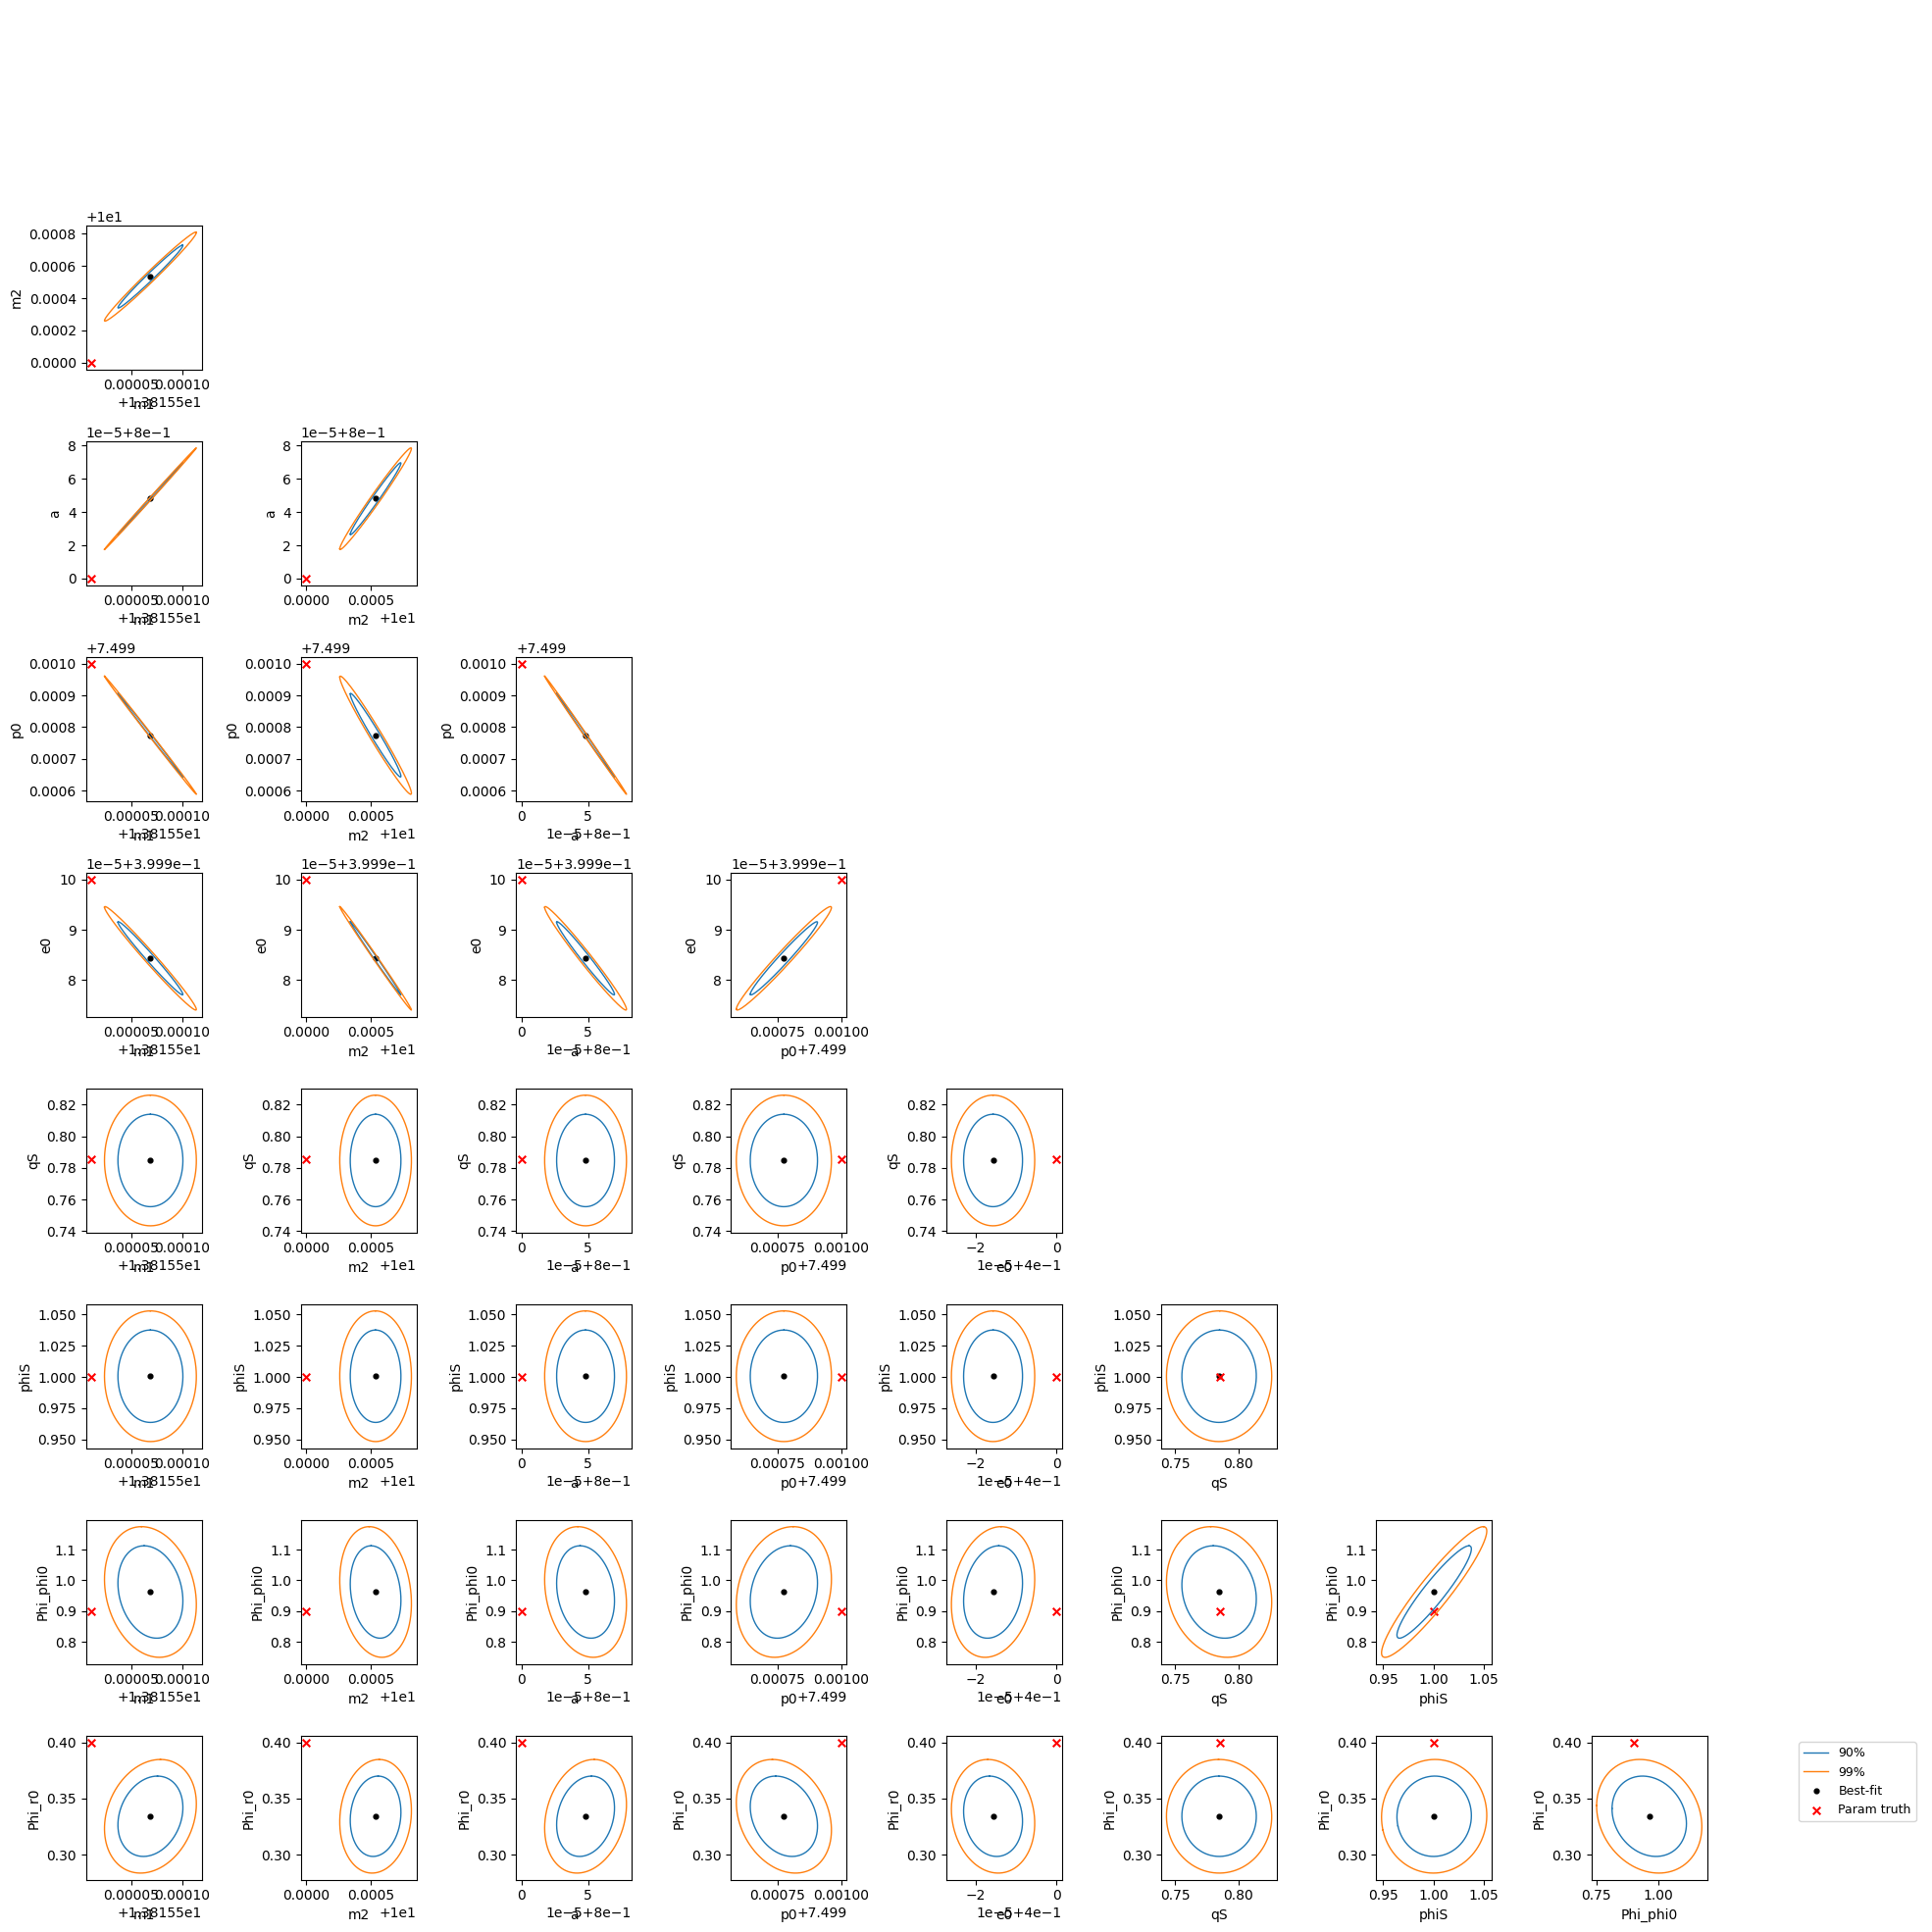

In [9]:
labels = param_names
triangle_plot(np.array(best_fit), cov, np.array(params_truth_in), labels,levels=[0.90, 0.99])


In [10]:
# True waveform with 1PA order
m1_true = 1e6
m2_true = 10
a_true = 0.8 
e0_true = 0.4 # 0.6 just spin first
xI0_true = 1.0
dist_true = 0.4
qS_true = xp.pi/4
phiS_true = 1.0
qK_true = 1 
phiK_true = xp.pi/3
Phi_phi0_true = 0.9
Phi_theta0_true =0.5
Phi_r0_true = 0.4
p0_true=7.5
chi2 = 0.0
dev_0_p_true=0.0
dev_0_e_true=0.0

evolve_1PA_true = True
evolve_primary = False
evolve_2PA = False
deviation_included=True

superkludge_wave = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=use_gpu)

add_args = [chi2, evolve_1PA_true, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,0,0,0,0]
waveform_true = superkludge_wave(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, dist_true, qS_true, phiS_true, qK_true, phiK_true, Phi_phi0_true, Phi_theta0_true, Phi_r0_true, *add_args, dt=dt, T=T)
waveform_true= xp.asarray(waveform_true)
fisher_derivs = xp.array(Fisher[0])
fisher_exact = xp.array(Fisher[-1])


In [11]:
# baseline check - 0PA model at true parameters
evolve_1PA_approx = False
add_args = [chi2, evolve_1PA_approx, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
waveform_approx = superkludge_wave(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, dist_true, qS_true, phiS_true, qK_true, phiK_true, Phi_phi0_true, Phi_theta0_true, Phi_r0_true, *add_args, dt=dt, T=T)
waveform_approx= xp.asarray(waveform_approx)

In [12]:
# waveform at best fit parameters with 0PA calaculated during fisher calculation
waveform_best_fit=sef.waveform
waveform_best_fit= xp.asarray(waveform_best_fit)

# waveform analysis and p0 evolution 

In [13]:
from few.utils.utility import ( 
    get_mismatch, 
    get_m2_at_t, 
    get_p_at_t, 
    )

from few.utils.geodesic import (
    get_fundamental_frequencies,
    get_separatrix,
    get_kerr_geo_constants_of_motion,
    ELQ_to_pex,
    )
SK_traj = EMRIInspiral(func=SuperKludgeFlux)
#get_p_at_t may fail with SuperKludge, especially with lower eccentricities, so we use KerrEccEq to generate p0 
add_args = [chi2, evolve_1PA_true, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
p_sep = get_separatrix(a_true, e0_true, xI0_true)
p0_should = get_p_at_t(traj_module=SK_traj, t_out=0.5, traj_args=[m1_true, m2_true, a_true, e0_true, xI0_true, *add_args])
print('should take p0 around for for true waveform: ', p0_should+0.1)
print('separatrix p: ', p_sep)

should take p0 around for for true waveform:  6.439843289124535
separatrix p:  3.3636344376256564


# P evolution is done considering true waveform (1PA)


[0.0, True, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


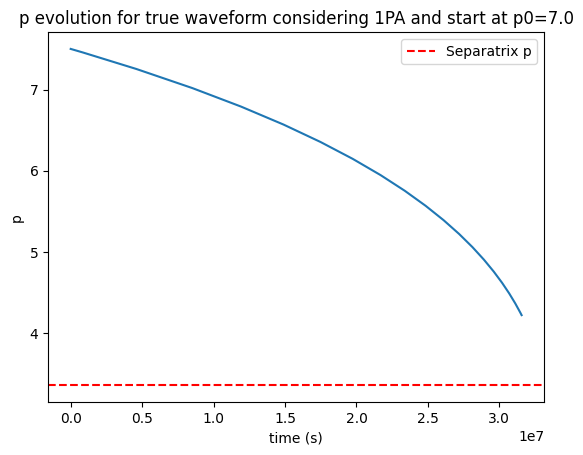

In [14]:
from scipy.interpolate import CubicSpline
add_args = [chi2, evolve_1PA_true, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
print(add_args) 
t_evol, p_evol, e_evol, x2_evol, pp2_evol, pt2_evol, pr2_evol, _, _ = SK_traj(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, *add_args,
                                               Phi_phi0=Phi_phi0_true, Phi_theta0=Phi_theta0_true, Phi_r0=Phi_r0_true, T=T, dt=dt)
p_evolution = CubicSpline(t_evol, p_evol)(t_evol)
plt.plot(t_evol, p_evolution)
plt.title('p evolution for true waveform considering 1PA and start at p0=7.0')
plt.xlabel('time (s)')
plt.ylabel('p')
plt.axhline(p_sep, color='red', linestyle='--', label='Separatrix p')
plt.legend()
plt.show()

# Waveform Visualization

# Overlap and mismatch

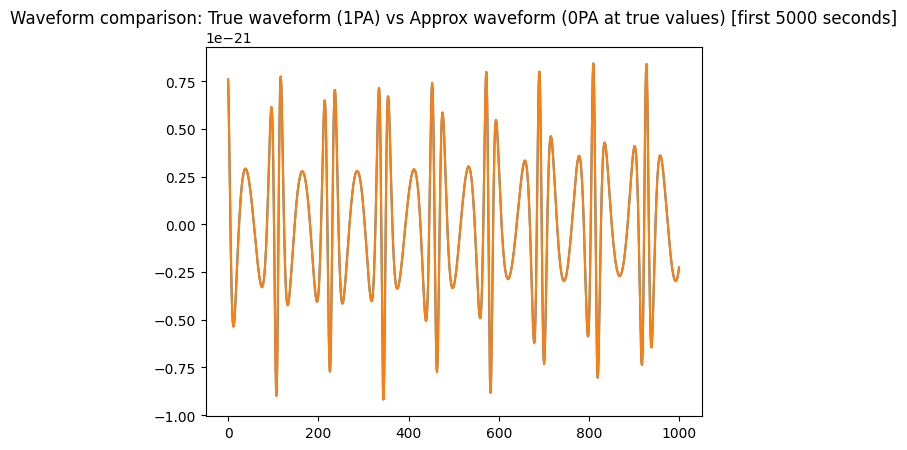

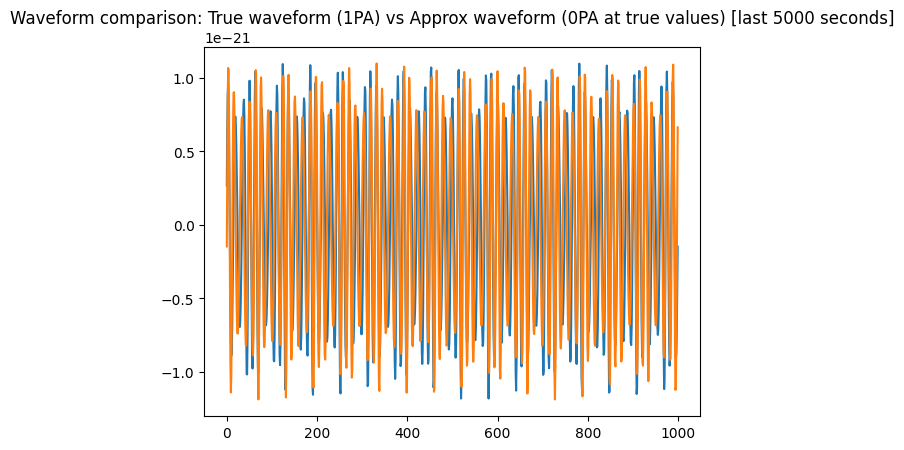

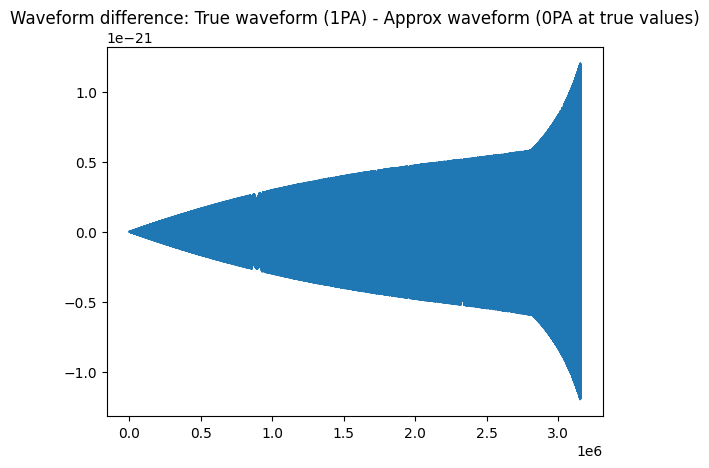

In [15]:
plt.plot(waveform_true[0][0:1000].get())
plt.plot(waveform_approx[0][0:1000].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at true values) [first 5000 seconds]')
plt.show()

plt.plot(waveform_true[0][-1000:].get())
plt.plot(waveform_approx[0][-1000:].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at true values) [last 5000 seconds]')
plt.show()
# waveform_approx
# waveform_best_fit
plt.plot((waveform_true[0]-waveform_approx[0]).get())
plt.title('Waveform difference: True waveform (1PA) - Approx waveform (0PA at true values)')
plt.show()

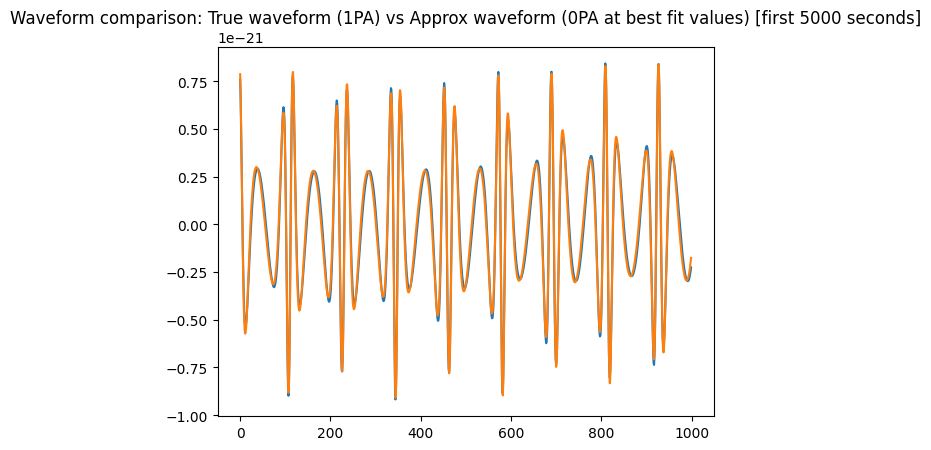

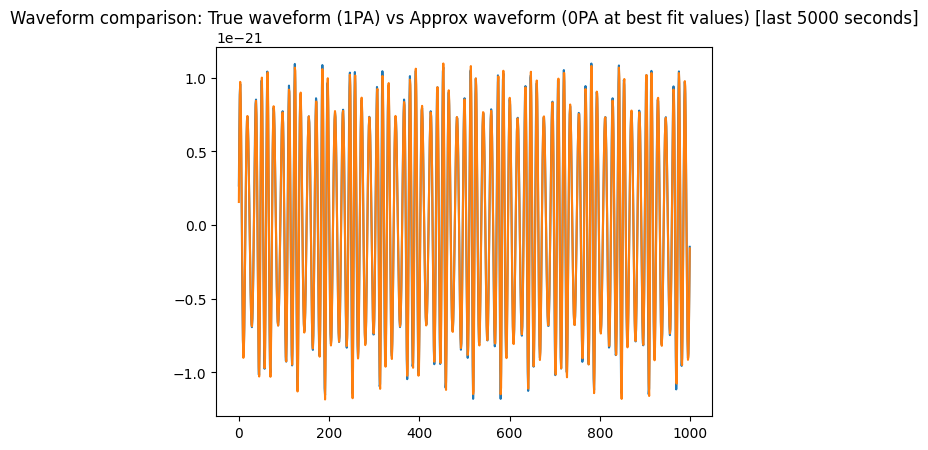

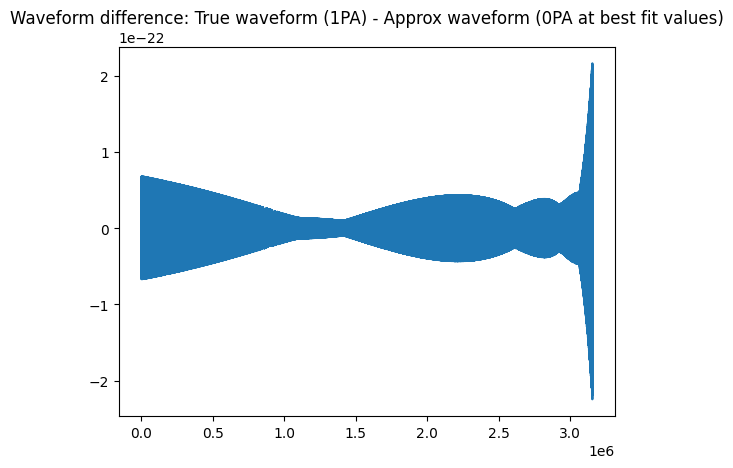

In [16]:
plt.plot(waveform_true[0][0:1000].get())
plt.plot(waveform_best_fit[0][0:1000].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at best fit values) [first 5000 seconds]')
plt.show()

plt.plot(waveform_true[0][-1000:].get())
plt.plot(waveform_best_fit[0][-1000:].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at best fit values) [last 5000 seconds]')
plt.show()
# waveform_approx
# waveform_best_fit
plt.plot((waveform_true[0]-waveform_best_fit[0]).get())
plt.title('Waveform difference: True waveform (1PA) - Approx waveform (0PA at best fit values)')
plt.show()

In [17]:
PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])
diff_inner_bf=inner_product(waveform_best_fit,waveform_true,PSD,dt,use_gpu=use_gpu)
norm_true=np.sqrt(inner_product(waveform_true,waveform_true,PSD,dt,use_gpu=use_gpu))
norm_bf=np.sqrt(inner_product(waveform_best_fit,waveform_best_fit,PSD,dt,use_gpu=use_gpu))
overlap_bf=diff_inner_bf/((norm_true)*norm_bf)
print("overlap between best fit point and true waveform:", overlap_bf)
print("mismatch between best fit point and true waveform:", 1-overlap_bf)

norm_approx=np.sqrt(inner_product(waveform_approx,waveform_approx,PSD,dt,use_gpu=use_gpu))
diff_inner_approx=inner_product(waveform_approx,waveform_true,PSD,dt,use_gpu=use_gpu)
overlap_approx=diff_inner_approx/((norm_true)*norm_approx)
print("overlap between approximate waveform and true waveform (both at true points)", overlap_approx)
print("mismatch between approximate waveform and true waveform (both at true points):", 1-overlap_approx)

overlap between best fit point and true waveform: 0.9993569130485225
mismatch between best fit point and true waveform: 0.0006430869514775228
overlap between approximate waveform and true waveform (both at true points) 0.9005241196983437
mismatch between approximate waveform and true waveform (both at true points): 0.09947588030165633


# Table true vs bias

In [18]:
best_fit

[13.81556871,
 10.00053383,
 0.80004804,
 7.49977467,
 0.39998433,
 0.78466984,
 1.00056143,
 0.96234993,
 0.33422898]

In [19]:
import pandas as pd
best_fit[0] = np.exp(13.81561299)
truue_param=[m1_true,m2_true,a_true,p0_true,e0_true,qS_true,phiS_true,Phi_phi0_true,Phi_r0_true]
df = pd.DataFrame({'Best Fit': best_fit, 'True Param': truue_param}, index=param_names)
print(df)

              Best Fit      True Param
m1        1.000102e+06  1000000.000000
m2        1.000053e+01       10.000000
a         8.000480e-01        0.800000
p0        7.499775e+00        7.500000
e0        3.999843e-01        0.400000
qS        7.846698e-01        0.785398
phiS      1.000561e+00        1.000000
Phi_phi0  9.623499e-01        0.900000
Phi_r0    3.342290e-01        0.400000


In [20]:
# #Orthoganal check between derivative and exact fisher matrices
# PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
#                 noise_PSD=get_sensitivity,
#                 noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
#                 channels=["A","E"])
# inner_val = []
# for i in range(fisher_derivs.shape[0]):
#     temp_deriv = inner_product(fisher_derivs[i],waveform_true-sef.waveform, PSD=PSD, dt=dt,use_gpu=use_gpu)
#     inner_val.append(temp_deriv)
